IMports

In [1]:
import numpy as np
import pandas as pd

from sklearn.ensemble import ExtraTreesRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

Load historical data

In [2]:
df = pd.read_csv("../data/processed/ratnapark/ratnapark_pm1_pm25_pm10_daily.csv")

df["date"] = pd.to_datetime(
    df["date"]
)

df = (
    df
    .sort_values("date")
    .reset_index(drop=True)
)

print("Historical shape:", df.shape)

display(df.head())
display(df.tail())

Historical shape: (1887, 4)


,date,pm1,pm2_5,pm10
0,2016-08-25,144.026083,187.599837,269.346300
1,2016-08-27,121.881565,159.537520,230.975440
2,2016-08-28,98.196718,124.696523,171.362190
3,2016-08-29,54.083770,63.915300,78.042140
4,2016-09-07,127.947061,168.501950,245.585955


,date,pm1,pm2_5,pm10
1882,2025-12-27,62.634761,73.584236,92.353125
1883,2025-12-28,59.609465,70.560069,89.774583
1884,2025-12-29,60.442938,70.737011,88.259249
1885,2025-12-30,62.676937,75.665342,99.304639
1886,2025-12-31,59.515977,73.188123,98.925535


Create change features

In [5]:
for pollutant in ["pm2_5", "pm10"]:

    df[
        f"{pollutant}_change_1"
    ] = (
        df[pollutant]
        - df[pollutant].shift(1)
    )

    df[
        f"{pollutant}_change_3"
    ] = (
        df[pollutant]
        - df[pollutant].shift(3)
    )

    df[
        f"{pollutant}_change_7"
    ] = (
        df[pollutant]
        - df[pollutant].shift(7)
    )

    df[
        f"{pollutant}_pct_change_1"
    ] = (
        df[pollutant]
        .pct_change(1)
    )

    df[
        f"{pollutant}_pct_change_3"
    ] = (
        df[pollutant]
        .pct_change(3)
    )

    df[
        f"{pollutant}_pct_change_7"
    ] = (
        df[pollutant]
        .pct_change(7)
    )

In [7]:
pm10_features = [
    "pm2_5_change_1",
    "pm2_5_change_3",
    "pm2_5_change_7",
    "pm2_5_pct_change_1",
    "pm2_5_pct_change_3",
    "pm2_5_pct_change_7",

    "pm10_change_1",
    "pm10_change_3",
    "pm10_change_7",
    "pm10_pct_change_1",
    "pm10_pct_change_3",
    "pm10_pct_change_7",
]

print("Features:", len(pm10_features))

Features: 12


Prepare whole historical data for training

In [8]:
train_df = df.dropna(
    subset=pm10_features + ["pm10"]
).copy()

print("Training rows:", len(train_df))

print(
    "Training date range:",
    train_df["date"].min(),
    "→",
    train_df["date"].max()
)

Training rows: 1880
Training date range: 2016-09-12 00:00:00 → 2025-12-31 00:00:00


In [9]:
X_train = train_df[
    pm10_features
]

y_train = train_df[
    "pm10"
]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

X_train: (1880, 12)
y_train: (1880,)


Train the model

In [10]:
final_pm10_model = ExtraTreesRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1,
)

final_pm10_model.fit(
    X_train,
    y_train
)

print("PM10 Extra Trees 500 trained successfully.")

PM10 Extra Trees 500 trained successfully.


Load unseen data

In [11]:
test_pm10 = pd.read_csv("../data/processed/ratnapark/ratnapark_pm10_test_15days.csv")

test_pm10["date"] = pd.to_datetime(
    test_pm10["date"]
)

test_pm10 = (
    test_pm10
    .sort_values("date")
    .reset_index(drop=True)
)

print("Test shape:", test_pm10.shape)

display(test_pm10)

Test shape: (8, 15)


,date,pm2_5,pm10,pm2_5_change_1,pm2_5_change_3,pm2_5_change_7,pm2_5_pct_change_1,pm2_5_pct_change_3,pm2_5_pct_change_7,pm10_change_1,pm10_change_3,pm10_change_7,pm10_pct_change_1,pm10_pct_change_3,pm10_pct_change_7
0,2026-08-09 00:00:00+00:00,10.405691,17.865232,-2.905274,-30.715306,-48.427848,-0.218262,-0.746949,-0.823133,-2.777516,-31.908332,-46.157019,-0.134552,-0.641070,-0.720953
1,2026-08-10 00:00:00+00:00,9.005760,16.479667,-1.399931,-11.725186,-53.629057,-0.134535,-0.565589,-0.856218,-1.385566,-15.185563,-58.913889,-0.077557,-0.479566,-0.781418
2,2026-08-11 00:00:00+00:00,15.107986,26.751389,6.102226,1.797022,-43.640698,0.677591,0.135003,-0.742837,10.271722,6.108641,-42.530113,0.623297,0.295922,-0.613874
3,2026-08-12 00:00:00+00:00,14.218958,26.608750,-0.889028,3.813268,-25.412980,-0.058845,0.366460,-0.641225,-0.142639,8.743518,-22.685646,-0.005332,0.489415,-0.460207
4,2026-08-13 00:00:00+00:00,14.537127,23.974670,0.318169,5.531367,-26.583870,0.022376,0.614203,-0.646479,-2.634080,7.495003,-25.798895,-0.098993,0.454803,-0.518325
5,2026-08-14 00:00:00+00:00,10.211659,17.667453,-4.325468,-4.896328,-10.519287,-0.297546,-0.324089,-0.507420,-6.307217,-9.083936,-13.997776,-0.263078,-0.339569,-0.442055
6,2026-08-15 00:00:00+00:00,10.299861,14.650798,0.088203,-3.919097,-3.011103,0.008637,-0.275625,-0.226212,-3.016655,-11.957952,-5.991950,-0.170746,-0.449399,-0.290269
7,2026-08-16 00:00:00+00:00,10.739167,18.176389,0.439305,-3.797960,0.333476,0.042652,-0.261259,0.032047,3.525591,-5.798281,0.311156,0.240642,-0.241850,0.017417


Precict values

In [12]:
X_test = test_pm10[
    pm10_features
]

y_test = test_pm10[
    "pm10"
]

predictions = final_pm10_model.predict(
    X_test
)

Add predictions

In [13]:
test_pm10["predicted_pm10"] = predictions

display(
    test_pm10[
        [
            "date",
            "pm10",
            "predicted_pm10"
        ]
    ]
)

,date,pm10,predicted_pm10
0,2026-08-09 00:00:00+00:00,17.865232,20.578782
1,2026-08-10 00:00:00+00:00,16.479667,18.581100
2,2026-08-11 00:00:00+00:00,26.751389,31.618920
3,2026-08-12 00:00:00+00:00,26.608750,32.803107
4,2026-08-13 00:00:00+00:00,23.974670,31.381605
5,2026-08-14 00:00:00+00:00,17.667453,16.931864
6,2026-08-15 00:00:00+00:00,14.650798,22.990120
7,2026-08-16 00:00:00+00:00,18.176389,24.077018


See out metrics

In [14]:
mae = mean_absolute_error(
    y_test,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

r2 = r2_score(
    y_test,
    predictions
)

print("=" * 60)
print("PM10 FINAL UNSEEN TEST RESULTS")
print("=" * 60)

print(f"MAE :  {mae:.3f}")
print(f"RMSE:  {rmse:.3f}")
print(f"R²  :  {r2:.3f}")

PM10 FINAL UNSEEN TEST RESULTS
MAE :  4.782
RMSE:  5.404
R²  :  -0.471


Here is mae and rmse is better than our split based , but \(R^{2}\) (R-squared), is negative 

Actual vs predicted

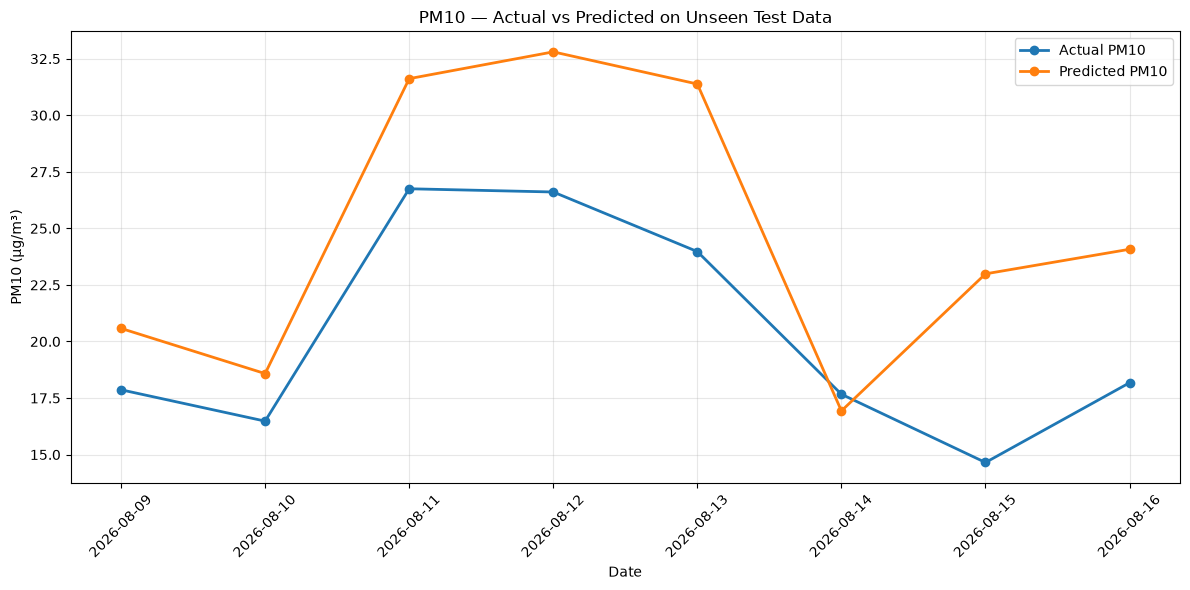

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    test_pm10["date"],
    test_pm10["pm10"],
    marker="o",
    linewidth=2,
    label="Actual PM10"
)

plt.plot(
    test_pm10["date"],
    test_pm10["predicted_pm10"],
    marker="o",
    linewidth=2,
    label="Predicted PM10"
)

plt.xlabel("Date")
plt.ylabel("PM10 (µg/m³)")

plt.title(
    "PM10 — Actual vs Predicted on Unseen Test Data"
)

plt.xticks(rotation=45)

plt.grid(
    True,
    alpha=0.3
)

plt.legend()

plt.tight_layout()
plt.show()

Forecast aug 17

In [17]:
forecast_df = pd.read_csv("../data/processed/ratnapark/ratnapark_pm10_test_15days.csv")

forecast_df["date"] = pd.to_datetime(
    forecast_df["date"]
)

forecast_df = (
    forecast_df
    .sort_values("date")
    .reset_index(drop=True)
)

In [18]:
latest = (
    forecast_df
    .sort_values("date")
    .iloc[-1]
)

print("Latest available date:")
print(latest["date"])

print("\nFeatures used for Aug 17 forecast:")

for feature in pm10_features:
    print(
        f"{feature}: {latest[feature]}"
    )

Latest available date:
2026-08-16 00:00:00+00:00

Features used for Aug 17 forecast:
pm2_5_change_1: 0.4393054437406043
pm2_5_change_3: -3.7979603519152185
pm2_5_change_7: 0.3334761514078632
pm2_5_pct_change_1: 0.0426515886831118
pm2_5_pct_change_3: -0.2612593500033759
pm2_5_pct_change_7: 0.0320474793474117
pm10_change_1: 3.5255908424565003
pm10_change_3: -5.798281449774599
pm10_change_7: 0.3111564320078095
pm10_pct_change_1: 0.2406415558543044
pm10_pct_change_3: -0.2418503095885159
pm10_pct_change_7: 0.0174168700194921


In [19]:
X_aug17 = pd.DataFrame(
    [
        [
            latest[feature]
            for feature in pm10_features
        ]
    ],
    columns=pm10_features
)

In [20]:
predicted_aug17_pm10 = (
    final_pm10_model
    .predict(X_aug17)[0]
)

print("=" * 60)
print("PM10 FORECAST")
print("=" * 60)

print("Forecast date: 2026-08-17")

print(
    f"Predicted PM10: "
    f"{predicted_aug17_pm10:.2f} µg/m³"
)

PM10 FORECAST
Forecast date: 2026-08-17
Predicted PM10: 24.08 µg/m³


Save the model

In [21]:
import joblib
from pathlib import Path

MODEL_DIR = Path("../models")

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

model_path = (
    MODEL_DIR /
    "pm10_extra_trees_500_change.joblib"
)

joblib.dump(
    final_pm10_model,
    model_path
)

print("PM10 model saved:")
print(model_path)

PM10 model saved:
..\models\pm10_extra_trees_500_change.joblib


Test model

In [22]:
loaded_pm10_model = joblib.load(
    "../models/pm10_extra_trees_500_change.joblib"
)

loaded_prediction = loaded_pm10_model.predict(
    X_aug17
)[0]

print(
    f"Loaded model prediction: "
    f"{loaded_prediction:.2f} µg/m³"
)

Loaded model prediction: 24.08 µg/m³
